In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np


In [2]:
data = load_diabetes()

In [3]:
data.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [5]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
from sklearn.model_selection import train_test_split

X = data.data
y = data.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.3,
  random_state=123
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

训练集大小: (309, 10)
测试集大小: (133, 10)


In [14]:
from sklearn.preprocessing import StandardScaler

X_sc = StandardScaler().fit(X_train)
y_sc = StandardScaler().fit(y_train)

X_train_scaled = X_sc.transform(X_train)
X_test_scaled = X_sc.transform(X_test)
y_train_scaled = y_sc.transform(y_train)
y_test_scaled = y_sc.transform(y_test)
print(f"训练集特征均值: {X_train_scaled.mean()}")
print(f"训练集特征标准差: {X_train_scaled.std()}")
print(f"训练集目标均值: {y_train_scaled.mean()}")
print(f"训练集目标标准差: {y_train_scaled.std()}")


训练集特征均值: 3.6791856867836903e-17
训练集特征标准差: 1.0
训练集目标均值: 9.197964216959226e-17
训练集目标标准差: 1.0


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)

print(f"模型系数: {lr.coef_.flatten()}")
print(f"模型截距: {lr.intercept_}")

模型系数: [ 0.00635274 -0.16173636  0.3362826   0.17507248 -0.54814214  0.30069969
  0.10371729  0.19815877  0.42739626  0.06756225]
模型截距: [1.039148e-16]


In [23]:
train_score = lr.score(X_train_scaled, y_train_scaled)
test_score = lr.score(X_test_scaled, y_test_scaled)
print(f"训练集得分: {train_score}")
print(f"测试集得分: {test_score}")


训练集得分: 0.5174981091172836
测试集得分: 0.5078253552814805


In [29]:
from sklearn.metrics import mean_squared_error

y_test_pred = lr.predict(X_test_scaled)
y_pred = y_sc.inverse_transform(y_test_pred)
y_test_orig = y_sc.inverse_transform(y_test_scaled)
mse = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
print(f"测试集均方误差: {mse}")
print(f"测试集均方根误差: {rmse}")

测试集均方误差: 2926.8196257936315
测试集均方根误差: 54.10008896289942


/var/folders/nl/8nf51sjx3r351yr6tqj78cbm0000gn/T/ipykernel_64273/4024759820.py:32: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  plt.tight_layout()
/var/folders/nl/8nf51sjx3r351yr6tqj78cbm0000gn/T/ipykernel_64273/4024759820.py:33: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  plt.savefig('linear_regression_eval.png', dpi=120, bbox_inches='tight')
/Users/godfather/Development/python-data-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


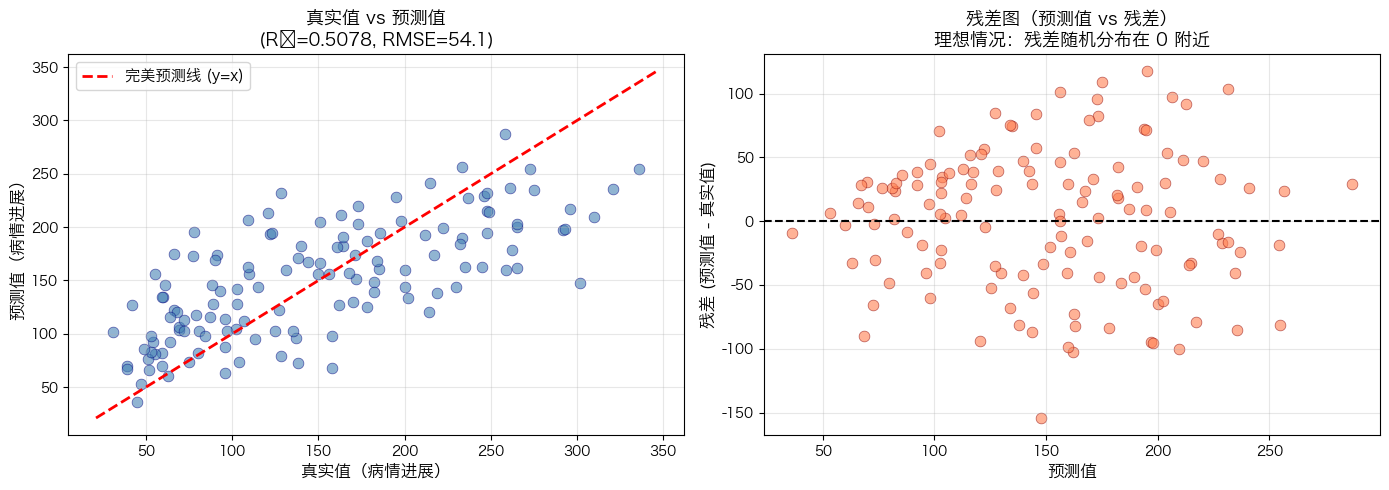

In [31]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(y_test_orig, y_pred, alpha=0.6, color='steelblue',
            edgecolors='navy', linewidths=0.5, s=60)

lim_min = min(y_test_orig.min(), y_pred.min()) - 10
lim_max = max(y_test_orig.max(), y_pred.max()) + 10
ax1.plot([lim_min, lim_max], [lim_min, lim_max],
         'r--', linewidth=2, label='完美预测线 (y=x)')
ax1.set_title(f'真实值 vs 预测值\n(R²={test_score:.4f}, RMSE={rmse:.1f})', fontsize=13)
ax1.set_xlabel('真实值（病情进展）', fontsize=12)
ax1.set_ylabel('预测值（病情进展）', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2 = axes[1]
residuals = (y_pred - y_test_orig).flatten()
ax2.scatter(y_pred.flatten(), residuals,
            alpha=0.6, color='coral', edgecolors='darkred', linewidths=0.5, s=60)
ax2.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax2.set_title('残差图（预测值 vs 残差）\n理想情况：残差随机分布在 0 附近', fontsize=13)
ax2.set_xlabel('预测值', fontsize=12)
ax2.set_ylabel('残差 (预测值 - 真实值)', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_eval.png', dpi=120, bbox_inches='tight')
plt.show()

### 决策树

In [34]:
from sklearn.datasets import load_wine

wine = load_wine()

print(f"特征名称: {wine.feature_names}")
print(f"目标类别: {wine.target_names}")
print(f"数据形状: {wine.data.shape}")

特征名称: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
目标类别: ['class_0' 'class_1' 'class_2']
数据形状: (178, 13)


In [35]:
df = pd.concat([
  pd.DataFrame(wine.data, columns=wine.feature_names),
  pd.DataFrame(wine.target, columns=['target'])
], axis=1)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  wine.data, wine.target,
  test_size=0.3,
  random_state=123
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

训练集大小: (124, 13)
测试集大小: (54, 13)


In [37]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
  criterion='entropy',
  random_state=123
)

clf.fit(X_train, y_train)

train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)
print(f"训练集准确率: {train_score:.4f}")
print(f"测试集准确率: {test_score:.4f}")

训练集准确率: 1.0000
测试集准确率: 0.9259


In [39]:
y_pred = clf.predict(X_test)

print(f"测试集预测结果: {y_pred[:10]}")
print(f"测试集真实标签: {y_test[:10]}")

测试集预测结果: [2 1 2 1 1 2 0 2 2 1]
测试集真实标签: [2 1 2 1 1 2 0 2 2 1]


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(cm)

print("\n分类报告:")
print(classification_report(y_test, y_pred))

混淆矩阵:
[[14  0  0]
 [ 1 17  0]
 [ 2  1 19]]

分类报告:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       0.94      0.94      0.94        18
           2       1.00      0.86      0.93        22

    accuracy                           0.93        54
   macro avg       0.92      0.94      0.92        54
weighted avg       0.94      0.93      0.93        54



In [45]:
# 中文特征名对照
feature_names_cn = {
    'alcohol': '酒精',
    'malic_acid': '苹果酸',
    'ash': '灰分',
    'alcalinity_of_ash': '灰分碱度',
    'magnesium': '镁',
    'total_phenols': '总酚',
    'flavanoids': '黄烷类酚',
    'nonflavanoid_phenols': '非黄烷类酚',
    'proanthocyanins': '花青素',
    'color_intensity': '颜色强度',
    'hue': '色调',
    'od280/od315_of_diluted_wines': '光学密度比',
    'proline': '脯氨酸'
}
feature_importances = clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
12,proline,0.412826
11,od280/od315_of_diluted_wines,0.245864
6,flavanoids,0.145155
3,alcalinity_of_ash,0.069875
0,alcohol,0.043172
10,hue,0.036356
9,color_intensity,0.025633
1,malic_acid,0.021120
2,ash,0.000000
4,magnesium,0.000000


    深度 |      训练准确率 |      测试准确率 |        差值（过拟合）
----------------------------------------------------
     1 |     0.5726 |     0.6667 |        -0.0941
     2 |     0.8468 |     0.8333 |         0.0134
     3 |     0.9274 |     0.8148 |         0.1126 ← 过拟合严重
     4 |     0.9839 |     0.8889 |         0.0950 ← 推荐
     5 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重
     6 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重
     7 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重
     8 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重
     9 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重
    10 |     1.0000 |     0.8704 |         0.1296 ← 过拟合严重


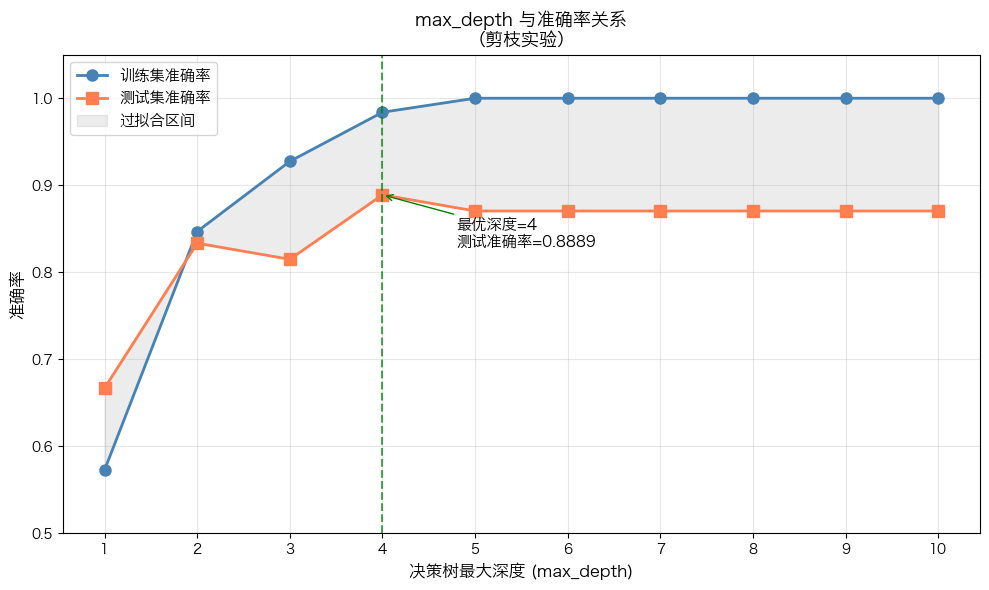

In [46]:
import matplotlib.pyplot as plt

train_scores = []
test_scores  = []
depth_range  = range(1, 11)

for depth in depth_range:
    clf_d = DecisionTreeClassifier(
        max_depth=depth,
        criterion="entropy",
        random_state=30,
        splitter="random"   # 随机选择分裂特征（增加多样性，防止局部最优）
    )
    clf_d.fit(X_train, y_train)
    train_scores.append(clf_d.score(X_train, y_train))
    test_scores.append(clf_d.score(X_test,  y_test))

# 打印详细数据
print(f"{'深度':>6} | {'训练准确率':>10} | {'测试准确率':>10} | {'差值（过拟合）':>14}")
print("-" * 52)
for d, (tr, te) in zip(depth_range, zip(train_scores, test_scores)):
    gap = tr - te
    flag = " ← 过拟合严重" if gap > 0.1 else (" ← 推荐" if te == max(test_scores) else "")
    print(f"  {d:4d} | {tr:10.4f} | {te:10.4f} | {gap:14.4f}{flag}")

# ── 可视化剪枝结果 ──
plt.figure(figsize=(10, 6))
plt.plot(list(depth_range), train_scores, 'o-', color='steelblue',
         linewidth=2, markersize=8, label='训练集准确率')
plt.plot(list(depth_range), test_scores, 's-', color='coral',
         linewidth=2, markersize=8, label='测试集准确率')
plt.fill_between(list(depth_range), train_scores, test_scores,
                 alpha=0.15, color='gray', label='过拟合区间')
best_depth = list(depth_range)[test_scores.index(max(test_scores))]
plt.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7)
plt.annotate(f'最优深度={best_depth}\n测试准确率={max(test_scores):.4f}',
             xy=(best_depth, max(test_scores)),
             xytext=(best_depth+0.8, max(test_scores)-0.06),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=11)
plt.xlabel('决策树最大深度 (max_depth)', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('max_depth 与准确率关系\n（剪枝实验）', fontsize=13)
plt.legend(fontsize=11)
plt.xticks(list(depth_range))
plt.ylim(0.5, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('decision_tree_depth.png', dpi=120, bbox_inches='tight')
plt.show()